# 🔬 Notebook 11: A Research-Grade Visualization Workflow

The first ten notebooks cover *what* Seaborn can draw. This notebook covers what a
figure needs before it can go into a paper, a thesis or a regulated report:

| Requirement | Tool in `seabornmasterpro` |
|---|---|
| Documented, regenerable data | `datasets.REGISTRY` data cards, `MANIFEST.json` |
| Uncertainty on every estimate | `stats.bootstrap_ci`, `stats.group_summary` |
| Effect sizes, not only p-values | `stats.cohens_d`, `hedges_g`, `cliffs_delta` |
| Multiple-comparison control | `stats.compare_groups(correction="holm" / "fdr_bh")` |
| Assumption-free alternatives | `test="mannwhitney"`, `test="permutation"` |
| Colour-vision-deficiency safety | `color.validate_palette`, `color.simulate_cvd` |
| Venue-specific figure geometry | `theme.journal_context`, `theme.figsize_for` |
| Provenance embedded in the file | `io.save_publication_figure` (PNG/PDF/SVG metadata) |
| Verifiable inputs | `repro.verify_manifest` |

Everything below is deterministic: the same seed yields the same numbers and the
same pixels.

**References.** Efron & Tibshirani (1993) *An Introduction to the Bootstrap*; Cohen (1988)
*Statistical Power Analysis*; Hedges (1981) *J. Educ. Stat.*; Cliff (1993) *Psychol. Bull.*;
Holm (1979) *Scand. J. Stat.*; Benjamini & Hochberg (1995) *J. R. Stat. Soc. B*;
Machado, Oliveira & Fernandes (2009) *IEEE TVCG*; W3C WCAG 2.1 §1.4.11.


In [1]:
# 📦 Setup
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:  # allows running without `pip install -e .`
    sys.path.insert(0, str(PROJECT_ROOT))

import seabornmasterpro as smp
from seabornmasterpro import annotate, color, datasets, io, layout, repro, stats, theme

DATA_DIR = PROJECT_ROOT / "datasets"
EXPORT = PROJECT_ROOT / "exports" / "11_research"

rng = smp.set_seed(2024)
smp.apply_theme(style="ticks", context="notebook", palette="colorblind")
print(f"seabornmasterpro {smp.__version__} · seaborn {sns.__version__} · pandas {pd.__version__}")

seabornmasterpro 2.0.0 · seaborn 0.13.2 · pandas 3.0.6


## 1. Start from a data card

Every dataset in `datasets/` is generated from a documented stochastic model. The
`clinical_trial` table plants a known dose-response effect, so we can check that the
analysis recovers it.

In [2]:
card = datasets.REGISTRY["clinical_trial"]
print(card.name, "—", card.description)
print("Generative model:", card.generative_model)
print("Seed:", card.seed_note)
pd.Series(card.columns, name="dtype / role").to_frame()

clinical_trial — Three-arm randomised trial with a planted dose-response effect.
Generative model: Outcome ~ N(μ_arm, σ_arm) + 0.15·(Baseline − 48); μ = (50, 53, 58), σ = (8, 10, 12). True Cohen's d: Placebo vs High ≈ 0.78, Placebo vs Low ≈ 0.33.
Seed: default_rng(2024)


,dtype / role
Arm,categorical (3)
Age,int
Sex,categorical (2)
Baseline,float
Outcome,float
Site,categorical (3)


In [3]:
trial = datasets.load("clinical_trial", data_dir=DATA_DIR)
ARMS = ["Placebo", "Low Dose", "High Dose"]
trial["Arm"] = pd.Categorical(trial["Arm"], categories=ARMS, ordered=True)
trial.groupby("Arm", observed=True)["Outcome"].agg(["count", "mean", "std"]).round(2)

,count,mean,std
Arm,,,
Placebo,60,48.61,8.46
Low Dose,60,50.50,9.49
High Dose,60,57.94,13.46


## 2. Estimates with bootstrap confidence intervals

Seaborn draws bootstrap error bars, but it does not hand you the numbers.
`group_summary` returns them as a tidy table so the figure and the text of the paper
agree exactly.

In [4]:
summary = stats.group_summary(trial, "Arm", "Outcome", n_boot=5000, seed=rng)
summary.round(2)

,Arm,n,estimate,low,high,confidence,n_boot,method
0,Placebo,60,48.61,46.47,50.80,0.95,5000,percentile
1,Low Dose,60,50.50,48.05,52.89,0.95,5000,percentile
2,High Dose,60,57.94,54.60,61.24,0.95,5000,percentile


✅ Plot saved to /Users/satvikpraveen/Documents/github_proj/SeabornMasterPro/exports/11_research/outcome_by_arm_bootstrap.png


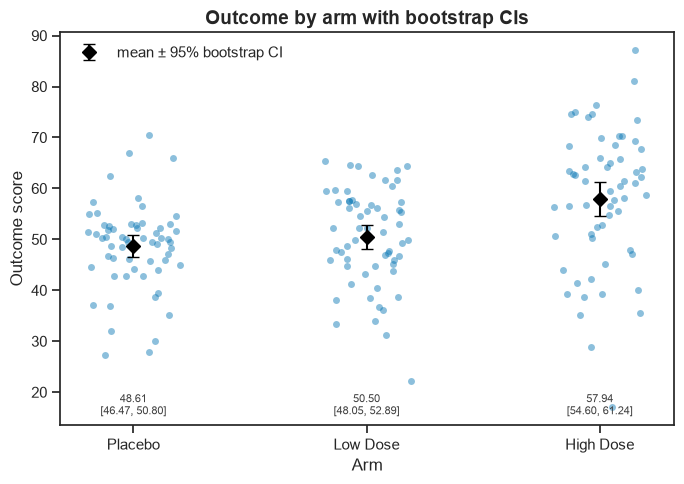

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(data=trial, x="Arm", y="Outcome", order=ARMS, alpha=0.45, jitter=0.2, ax=ax, legend=False)
ax.errorbar(
    x=np.arange(len(ARMS)),
    y=summary["estimate"],
    yerr=[summary["estimate"] - summary["low"], summary["high"] - summary["estimate"]],
    fmt="D", color="black", capsize=4, markersize=7, zorder=3, label="mean ± 95% bootstrap CI",
)
annotate.annotate_effect_sizes(ax, summary, "Arm")
ax.legend(loc="upper left", frameon=False)
annotate.stylize_plot(title="Outcome by arm with bootstrap CIs", xlabel="Arm", ylabel="Outcome score", ax=ax)
smp.save_fig(EXPORT / "outcome_by_arm_bootstrap.png", fig=fig)
plt.show()

## 3. Pairwise comparisons with multiplicity control

Three arms give three comparisons. `compare_groups` runs Welch's *t* on each pair,
adjusts the *p*-values with the Holm step-down procedure (family-wise error control),
and reports Hedges' *g* alongside. Effect sizes are signed as *group_a − group_b*, so a
negative *g* here means the second arm scored higher.

In [6]:
pairwise = stats.compare_groups(trial, "Arm", "Outcome", test="welch", correction="holm", order=ARMS)
pairwise[["group_a", "group_b", "statistic", "p_value", "p_adjusted", "effect_size", "effect_label", "stars"]].round(4)

,group_a,group_b,statistic,p_value,p_adjusted,effect_size,effect_label,stars
0,Placebo,Low Dose,-1.1488,0.2530,0.2530,-0.2084,small,ns
1,Placebo,High Dose,-4.5450,0.0000,0.0000,-0.8245,large,***
2,Low Dose,High Dose,-3.5001,0.0007,0.0014,-0.6350,medium,**


✅ Plot saved to /Users/satvikpraveen/Documents/github_proj/SeabornMasterPro/exports/11_research/pairwise_brackets.png


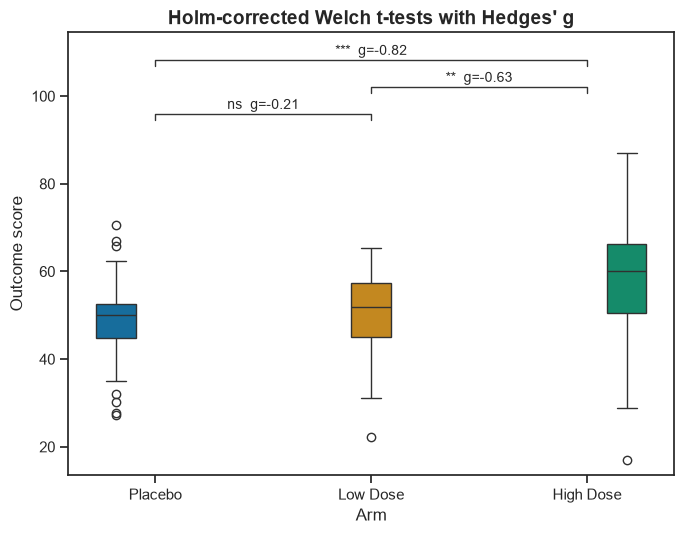

In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.boxplot(data=trial, x="Arm", y="Outcome", order=ARMS, hue="Arm", legend=False, width=0.55, ax=ax)
annotate.annotate_pairwise(ax, pairwise, order=ARMS, show_effect=True)
annotate.stylize_plot(title="Holm-corrected Welch t-tests with Hedges' g", ylabel="Outcome score", ax=ax)
smp.save_fig(EXPORT / "pairwise_brackets.png", fig=fig)
plt.show()

## 4. Do the conclusions depend on the test?

A robust result survives a change of estimator. Compare the adjusted *p*-values from a
parametric test, a rank test and a permutation test on the same pairs.

In [8]:
tests = ["welch", "mannwhitney", "permutation"]
frames = [
    stats.compare_groups(trial, "Arm", "Outcome", test=t, correction="holm", order=ARMS, seed=0, n_permutations=4000)
    for t in tests
]
robust = pd.concat(frames)
robust["pair"] = robust["group_a"] + " vs " + robust["group_b"]
robust.pivot(index="pair", columns="test", values="p_adjusted").round(4)

test,mannwhitney,permutation,welch
pair,,,
Low Dose vs High Dose,0.0005,0.0010,0.0014
Placebo vs High Dose,0.0000,0.0007,0.0000
Placebo vs Low Dose,0.1699,0.2644,0.2530


## 5. Recovering the planted effect

The data card states the true standardized difference between Placebo and High Dose is
about *d* ≈ 0.78. Sample estimates should land near it, with a bootstrap interval that
covers it.

In [9]:
placebo = trial.loc[trial["Arm"] == "Placebo", "Outcome"].to_numpy()
high = trial.loc[trial["Arm"] == "High Dose", "Outcome"].to_numpy()

d = stats.cohens_d(high, placebo)
g = stats.hedges_g(high, placebo)
delta = stats.cliffs_delta(high, placebo)

# Bootstrap the effect size itself by resampling each arm independently.
boot = np.empty(3000)
for i in range(boot.size):
    boot[i] = stats.cohens_d(rng.choice(high, high.size), rng.choice(placebo, placebo.size))
lo, hi = np.percentile(boot, [2.5, 97.5])

pd.DataFrame(
    {
        "estimate": [d, g, delta],
        "interpretation": [stats.interpret_effect_size(d), stats.interpret_effect_size(g), stats.interpret_effect_size(delta, "delta")],
    },
    index=["Cohen's d", "Hedges' g", "Cliff's δ"],
).round(3).assign(note=[f"95% bootstrap CI [{lo:.2f}, {hi:.2f}]; planted ≈ 0.78", "", ""])

,estimate,interpretation,note
Cohen's d,0.830,large,"95% bootstrap CI [0.47, 1.29]; planted ≈ 0.78"
Hedges' g,0.825,large,
Cliff's δ,0.482,large,


## 6. Palettes that survive colour-vision deficiency

About 8% of men have a red-green deficiency. `validate_palette` simulates protanopia,
deuteranopia and tritanopia (Machado et al., 2009) and reports the smallest CIELAB
distance between any two colours, plus WCAG contrast against the background.

Note that the `passes` column is strict: most default palettes contain a light yellow
whose contrast against white is below the 3:1 graphics threshold. That is a real
finding, and the usual fix is a thin dark edge on light marks or a light-grey background.

In [10]:
rows = []
for name in ["colorblind", "deep", "Set1", "tab10", "pastel"]:
    rep = color.validate_palette(name, threshold=10)
    rows.append({"palette": name, "n": rep.n_colors, "min ΔE (normal)": rep.min_delta_e, **{f"min ΔE ({k[:5]})": v for k, v in rep.min_delta_e_cvd.items()}, "min contrast on white": rep.min_contrast_on_white, "passes": rep.passes})
pd.DataFrame(rows).round(1).set_index("palette")

,n,min ΔE (normal),min ΔE (prota),min ΔE (deute),min ΔE (trita),min contrast on white,passes
palette,,,,,,,
colorblind,10,20.7,11.3,10.8,11.7,1.4,False
deep,10,16.1,2.7,8.6,9.8,2.0,False
Set1,9,32.7,3.7,9.9,17.6,1.1,False
tab10,10,27.7,4.6,7.2,15.2,2.0,False
pastel,10,20.8,4.8,1.8,7.8,1.1,False


✅ Plot saved to /Users/satvikpraveen/Documents/github_proj/SeabornMasterPro/exports/11_research/palette_cvd_simulation.png


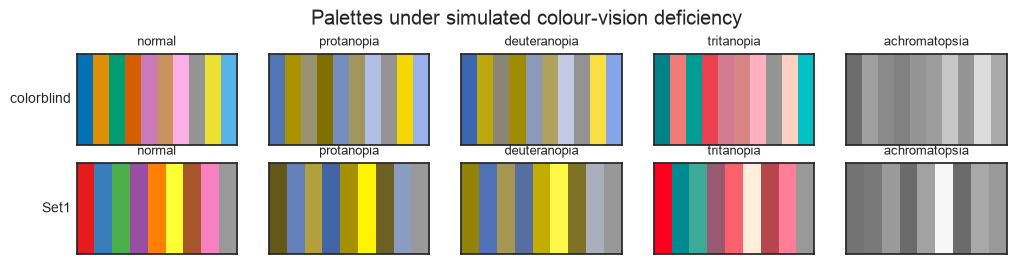

In [11]:
def show_cvd(palette: str, ax_row):
    grid = color.cvd_palette_grid(palette)
    for ax, (kind, rgb) in zip(ax_row, grid.items()):
        ax.imshow(rgb[None, :, :], aspect="auto")
        ax.set_title(kind, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    ax_row[0].set_ylabel(palette, rotation=0, ha="right", va="center", fontsize=10)

fig, axes = plt.subplots(2, 5, figsize=(12, 2.6))
show_cvd("colorblind", axes[0])
show_cvd("Set1", axes[1])
fig.suptitle("Palettes under simulated colour-vision deficiency", y=1.05)
smp.save_fig(EXPORT / "palette_cvd_simulation.png", fig=fig)
plt.show()

## 7. A journal-ready multi-panel figure with embedded provenance

`journal_context` sets the exact column width, font sizes and line weights for a venue
and restores your settings afterwards. `save_publication_figure` writes PNG, PDF and
SVG and embeds the environment (package versions, git revision, timestamp) into each
file's metadata so a reviewer can trace any figure back to the code that made it.

✅ Plot saved to /Users/satvikpraveen/Documents/github_proj/SeabornMasterPro/exports/11_research/figure1_trial.png


✅ Plot saved to /Users/satvikpraveen/Documents/github_proj/SeabornMasterPro/exports/11_research/figure1_trial.pdf
✅ Plot saved to /Users/satvikpraveen/Documents/github_proj/SeabornMasterPro/exports/11_research/figure1_trial.svg


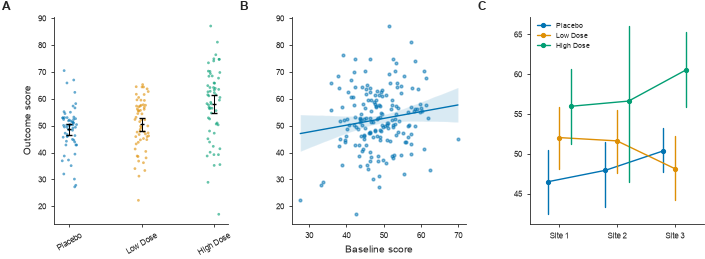

Figure width 7.20 in = 183 mm (Nature double column)


In [12]:
with theme.journal_context("nature", columns=2) as spec:
    w, h = theme.figsize_for("nature", columns=2, aspect=2.6)
    fig, axes = plt.subplots(1, 3, figsize=(w, h))

    sns.stripplot(data=trial, x="Arm", y="Outcome", order=ARMS, hue="Arm", legend=False, size=2, alpha=0.6, ax=axes[0])
    axes[0].errorbar(np.arange(3), summary["estimate"], yerr=[summary["estimate"] - summary["low"], summary["high"] - summary["estimate"]], fmt="_", color="black", capsize=2, zorder=3)
    axes[0].set(xlabel="", ylabel="Outcome score")
    axes[0].tick_params(axis="x", rotation=30)

    sns.regplot(data=trial, x="Baseline", y="Outcome", scatter_kws={"s": 4, "alpha": 0.5}, line_kws={"lw": 1}, ax=axes[1])
    axes[1].set(xlabel="Baseline score", ylabel="")

    sns.pointplot(data=trial, x="Site", y="Outcome", order=["Site 1", "Site 2", "Site 3"], hue="Arm", hue_order=ARMS, dodge=0.4, errorbar=("ci", 95), markersize=3, linewidth=1, ax=axes[2])
    axes[2].set(xlabel="", ylabel="")
    axes[2].legend(title=None, fontsize=spec.min_font_size, loc="upper left")

    sns.despine(fig)
    layout.label_panels(axes, fmt="{}", loc=(-0.25, 1.02))
    fig.tight_layout(w_pad=1.0)
    written = io.save_publication_figure(fig, EXPORT / "figure1_trial", formats=("png", "pdf", "svg"), dpi=600)
    plt.show()

print(f"Figure width {w:.2f} in = {w * 25.4:.0f} mm ({spec.name} double column)")

In [13]:
from PIL import Image

png_meta = Image.open(written[0]).info
provenance = json.loads(png_meta["Provenance"])
{k: provenance[k] for k in ("timestamp_utc", "python", "git_revision", "packages")}

{'timestamp_utc': '2026-09-27T04:47:26+00:00',
 'python': '3.13.13',
 'git_revision': 'cdba0f1',
 'packages': {'matplotlib': '3.11.2',
  'numpy': '2.5.3',
  'pandas': '3.0.6',
  'scipy': '1.18.1',
  'seaborn': '0.13.2',
  'sklearn': '1.9.1',
  'statsmodels': '0.15.0'}}

## 8. Time series with labelled anomalies

`sensor_readings` contains hourly data from three sensors with a diurnal cycle, weekly
seasonality, a slow drift and 0.4% injected outliers. Resampling to daily means keeps
the trend legible; the anomaly flags stay on the raw scale.

✅ Plot saved to /Users/satvikpraveen/Documents/github_proj/SeabornMasterPro/exports/11_research/sensor_daily_anomalies.png


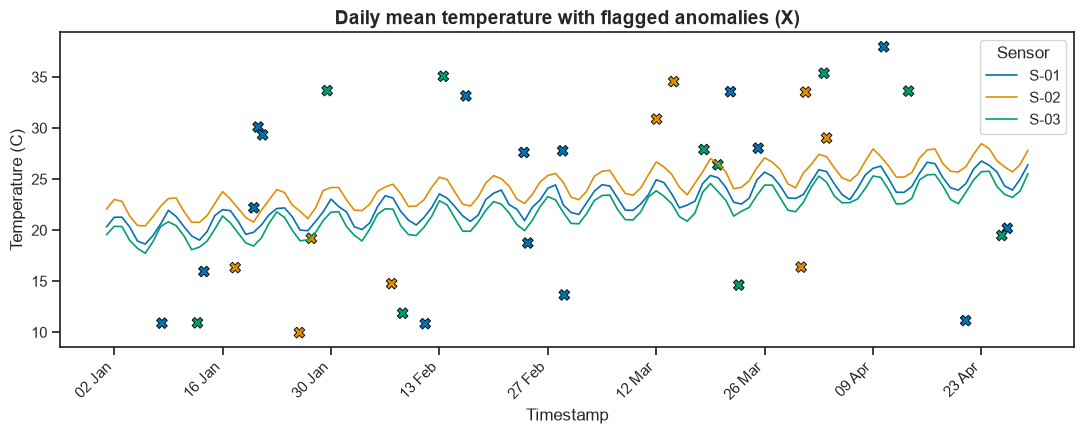

35 anomalies across 3 sensors


In [14]:
sensors = datasets.load("sensor_readings", data_dir=DATA_DIR)
daily = sensors.groupby(["Sensor", pd.Grouper(key="Timestamp", freq="D")], observed=True)["Temperature (C)"].mean().reset_index()
anoms = sensors[sensors["Anomaly"]]

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(data=daily, x="Timestamp", y="Temperature (C)", hue="Sensor", linewidth=1.2, ax=ax)
sns.scatterplot(data=anoms, x="Timestamp", y="Temperature (C)", hue="Sensor", marker="X", s=60, edgecolor="black", legend=False, ax=ax)
layout.format_date_axis(ax, date_format="%d %b", major_locator="week", interval=2, rotate_xticks=45)
annotate.stylize_plot(title="Daily mean temperature with flagged anomalies (X)", xlabel="", ax=ax)
smp.save_fig(EXPORT / "sensor_daily_anomalies.png", fig=fig)
plt.show()
print(f"{len(anoms)} anomalies across {sensors['Sensor'].nunique()} sensors")

## 9. Hierarchical clustering of an expression matrix

`gene_expression` is a wide log₂ matrix with two co-regulated modules. Row-wise
z-scoring, a diverging colormap and annotation strips for module and condition make
the structure visible without any tuning.

✅ Plot saved to /Users/satvikpraveen/Documents/github_proj/SeabornMasterPro/exports/11_research/gene_expression_clustermap.png


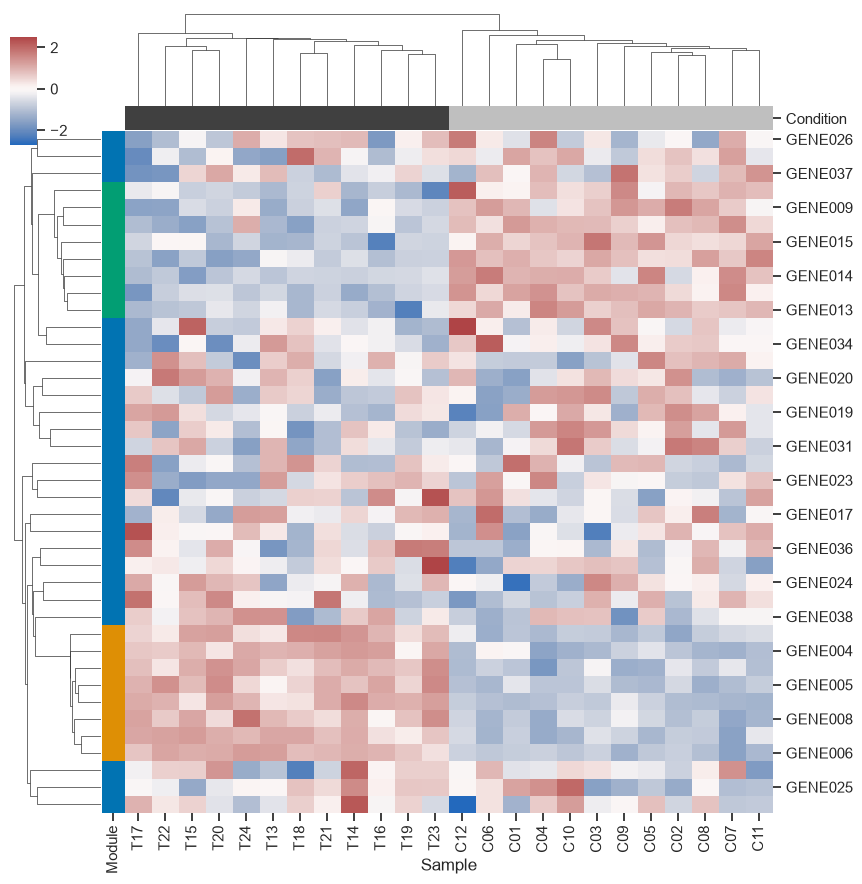

In [15]:
genes = datasets.load("gene_expression", data_dir=DATA_DIR).set_index("Gene")
matrix = genes.drop(columns="Module")
module_colors = genes["Module"].map(dict(zip(sorted(genes["Module"].unique()), sns.color_palette("colorblind", 3))))
cond = pd.Series(["Control" if c.startswith("C") else "Treated" for c in matrix.columns], index=matrix.columns, name="Condition")
cond_colors = cond.map({"Control": "0.75", "Treated": "0.25"})

cg = sns.clustermap(matrix, z_score=0, cmap="vlag", center=0, row_colors=module_colors.rename("Module"), col_colors=cond_colors, figsize=(9, 9), dendrogram_ratio=0.12, cbar_pos=(0.02, 0.83, 0.03, 0.12))
cg.ax_heatmap.set_xlabel("Sample"); cg.ax_heatmap.set_ylabel("")
smp.save_fig(EXPORT / "gene_expression_clustermap.png", fig=cg.figure)
plt.show()

## 10. Verify the inputs before you trust the outputs

`datasets/MANIFEST.json` records a SHA-256 digest of every CSV plus the environment
that generated it. Checking it takes one line and catches silent edits.

In [16]:
checks = repro.verify_manifest(DATA_DIR / "MANIFEST.json")
pd.Series(checks, name="matches manifest").to_frame()

,matches manifest
clinical_trial.csv,True
ecommerce_data.csv,True
employee_data.csv,True
gene_expression.csv,True
marketing_campaign.csv,True
sales_data.csv,True
sensor_readings.csv,True
student_scores.csv,True
web_traffic.csv,True


## Summary

* Estimates carry bootstrap intervals, and the numbers behind the figure are a table you can cite.
* Every *p*-value is adjusted for the number of comparisons, and every comparison reports an effect size.
* The conclusion was checked against parametric, rank-based and permutation tests.
* Colours were validated under simulated colour-vision deficiency.
* Figures were exported at the venue's exact geometry with provenance embedded in the file.
* The data were verified against a manifest before use.

See `docs/methodology.md` for the estimators, and `tests/` for the properties each of
these functions is checked against.